In [11]:
# %matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import time

from pyRTC import *
from pyRTC.hardware import *
from pyRTC.utils import *
from pyRTC.Pipeline import *
from pyRTC.SlopesProcess import computeSlopesSHWFSOptimNumba

conf = read_yaml_file("/home/whetstone/pyRTC_backup/SHARP_LAB/config.yaml")

In [12]:
# psfshm, _, psfDtype = initExistingShm("psfLong")
# psfShortShm, _, _ = initExistingShm("psfShort")
# strehlshm, _, _ = initExistingShm("strehl")
# slopeshm, _, _ = initExistingShm("signal")
# slopeshm2D, _, s2DDtype = initExistingShm("signal2D")
# wfc2D, _, _ = initExistingShm("wfc2D")
wfsShm, wfsImageShape, wfsImageDType = initExistingShm("wfs") #, gpuDevice = self.gpuDevice)

# %% Launch slopes
confSlopes = conf["slopes"]
slopes = SlopesProcess(conf=confSlopes)
slopes.start()
time.sleep(0.5)

In [13]:
image = wfsShm.read_noblock()
slope_signal, pupil_signal = computeSlopesSHWFSOptimNumba(image = image,
                            slopes = np.zeros_like(slopes.refSlopes), 
                            pupil = np.zeros(slopes.pupilShape),
                            unaberratedSlopes = slopes.refSlopes,
                            threshold = slopes.imageNoise*slopes.shwfsContrast, 
                            spacing = slopes.subApSpacing,
                            xvals = slopes.xvals,
                            offsetX = slopes.offsetX,
                            offsetY = slopes.offsetY,
                            intN = slopes.regionSize)
slope_out = slope_signal[slopes.validSubAps]

print(slope_signal.shape)
print(slope_out.shape)

In [14]:
import matplotlib.patches as patches
from matplotlib.pyplot import cm
import itertools

def drawSubapertures(image:np.ndarray, 
                        slopes:np.ndarray, 
                        unaberratedSlopes:np.ndarray, 
                        threshold:np.float32, 
                        spacing:np.float32,
                        xvals:np.ndarray,
                        offsetX:int, 
                        offsetY:int,
                        intN:int,
                        ):
    
    # Convert image to the same dtype as unaberratedSlopes
    image = image.astype(np.float32)
    image[image < threshold] = 0
    # Compute the number of sub-apertures
    numRegions = unaberratedSlopes.shape[1]

    fig = plt.figure(figsize=(20,20))
    plt.clf()

    ax = fig.add_subplot(111, aspect='equal')

    # Display the image
    ax.imshow(image)
    rects = 0
    color = itertools.cycle(cm.rainbow(np.linspace(0, 1, (numRegions) // 3)))

    # Loop over all regions
    for i in range(numRegions):
        for j in range(numRegions):
            # Compute where to start
            start_i = int(round(spacing * i)) + offsetY
            start_j = int(round(spacing * j)) + offsetX
            cc = next(color)
            # Ensure we stay within the bounds of the image
            # if start_j + intN <= image.shape[1] and start_i + intN <= image.shape[0]:
            rect = patches.Rectangle((start_i, start_j), intN, intN, linewidth=1, edgecolor=cc, facecolor='none', alpha=0.5)
            ax.add_patch(rect)
            rects += 1

            #     #Create a local subimage around the lenslet spot
            #     sub_im = image[start_i:start_i + intN, start_j:start_j + intN]

            #     #loop through the sub image
            #     norm = np.float32(0)
            #     weightX = np.float32(0)
            #     weightY = np.float32(0)
            #     for m in range(intN):
            #         for n in range(intN):
            #             #If we are counting the pixel
            #             if sub_im[m,n] > threshold:
            #                 #Add it to the normalization
            #                 norm += sub_im[m,n]
            #                 #Compute the X and Y centroids (before normalization)
            #                 weightX += xvals[m,n] * sub_im[m,n]
            #                 weightY += xvals[n,m] * sub_im[m,n]

            #     #If we have flux in the sub aperture
            #     if norm > 0:
            #         #Normalize the centroids and remove the reference slope
            #         slopes[i, j] = weightX/norm - unaberratedSlopes[i, j]
            #         slopes[i + numRegions, j] = weightY/norm - unaberratedSlopes[i + numRegions, j]
            #     #If we have no flux slopes should be zero

    plt.show()

    return rects

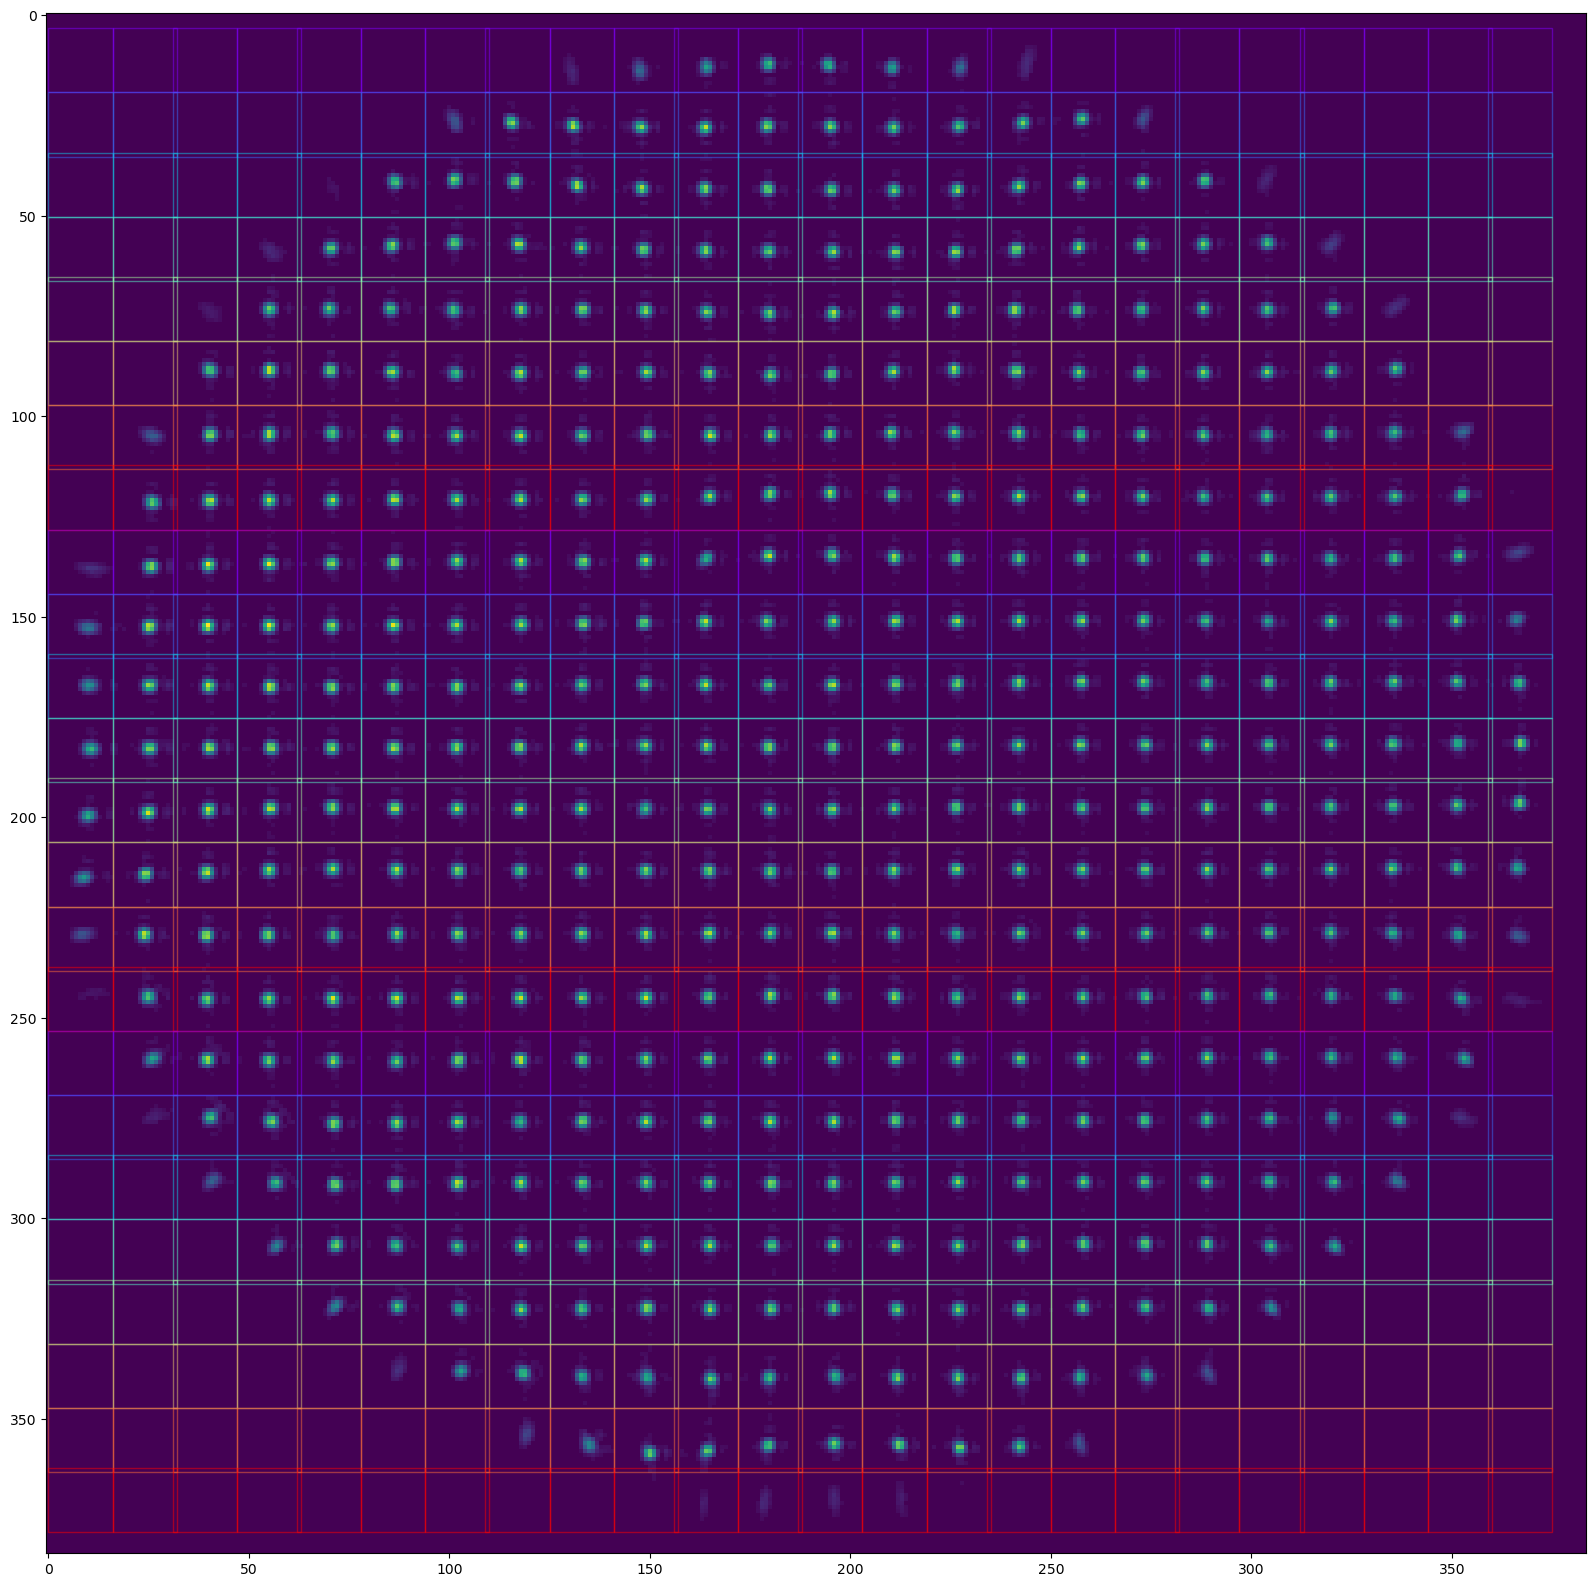

In [15]:
image = wfsShm.read_noblock()
num_rect = drawSubapertures(image = image,
                            slopes = np.zeros_like(slopes.refSlopes), 
                            unaberratedSlopes = slopes.refSlopes,
                            threshold = slopes.imageNoise*slopes.shwfsContrast, 
                            spacing = slopes.subApSpacing,
                            xvals = slopes.xvals,
                            offsetX = slopes.offsetX,
                            offsetY = slopes.offsetY,
                            intN = slopes.regionSize)

print(num_rect)

In [16]:
slopes.refSlopes.shape


(48, 24)